In [1]:
# Imports
import pandas as pd
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import os
import random
from joblib import dump, load
from collections import Counter
import warnings

# Métricas e ferramentas de Machine Learning
from imblearn.over_sampling import SMOTE
from sklearn import preprocessing
from scipy.spatial.distance import cdist
from cuml.ensemble import RandomForestClassifier as CuMLRF
from sklearn.ensemble import RandomForestClassifier as SkRF
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,classification_report,confusion_matrix)
import shap

dados = pd.read_csv ("../Databases/base_treino_boruta.csv", sep=',')
dados

<frozen importlib._bootstrap_external>:1184: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
<frozen importlib._bootstrap_external>:1184: FutureWarning: The cuda.cuda module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.driver module instead.
/home/cassi/miniconda3/envs/gpu_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,sample_id,MIMAT0000070,MIMAT0000103,MIMAT0003240,MIMAT0004592,MIMAT0004602,MIMAT0004804,MIMAT0005586,MIMAT0007347,MIMAT0016849,...,MIMAT0027478,MIMAT0027498,MIMAT0027540,MIMAT0027574,MIMAT0027575,MIMAT0027660,MIMAT0027686,MIMAT0031000,target,split
0,GSM2278615,1.030720,1.152392,-0.321811,-0.388305,-0.632559,-0.006389,-0.173028,0.734924,-0.538253,...,0.558312,0.682544,-0.281433,-0.152731,-0.136623,0.091852,-0.503763,1.053621,1,train
1,GSM2278616,1.773204,0.953377,-0.173949,-0.473914,-0.558560,0.032618,0.436156,0.842601,-0.515910,...,2.327494,0.270474,-1.432550,0.126085,1.908569,-0.476252,-0.810687,0.903694,1,train
2,GSM2278617,0.684740,0.403192,-0.496596,-0.608497,-0.066235,-1.190762,2.336523,0.121293,-0.042676,...,0.379008,0.212516,-0.912393,2.028289,-0.133262,-1.409829,-0.114039,0.013329,1,train
3,GSM2278618,-0.794088,-1.039456,-0.325646,-0.392525,-0.382181,-0.085807,0.056988,1.684487,-0.236236,...,1.159776,-0.186710,-1.223107,0.149769,-0.128983,-1.642710,0.321930,0.527365,1,train
4,GSM2278619,-1.453257,-0.910481,-0.491062,-0.424341,-0.479572,-0.036304,0.178505,0.631550,-0.728127,...,-0.839302,-0.348432,-0.809020,0.294022,0.486672,-1.282433,-1.035871,0.367641,1,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,GSM1447837,1.328089,0.849867,1.410876,2.054690,1.477953,1.944974,-0.440131,-0.042935,-0.007901,...,-0.860789,-0.101230,0.246102,-0.030673,-1.283171,1.365195,0.346937,-0.132385,0,train
281,GSM1447839,-1.429717,-1.267393,1.671507,2.089174,1.935565,-0.035735,0.167215,-0.624830,0.249774,...,-1.316962,1.582785,1.226486,-3.219079,-1.514643,2.006021,1.122274,-2.233914,0,train
282,GSM1447840,-0.345422,-0.366692,1.147987,1.722085,1.612545,0.596328,-0.269979,-1.103681,0.572284,...,-0.574166,-0.939608,2.324517,-1.450733,-0.072031,0.567534,1.845342,-0.367161,0,train
283,GSM1447841,-0.365179,-1.267393,0.078382,1.693163,1.418407,0.877449,-1.697361,-0.624830,0.445940,...,0.511769,-0.565786,0.997730,-1.529889,0.126708,0.120642,1.411211,1.093030,0,train


In [2]:
# normalizar
# remover colunas que não são features
dados_num = dados.drop(columns=["sample_id", "target", "split"])

# target (0/1) separado como categorico
dados_cat = dados[["target"]]

# Instanciar o objeto normalizador
normalizador = preprocessing.MinMaxScaler()

# treinar o normalizador apenas nas features
modelo_normalizador_num = normalizador.fit(dados_num)

# salvando modelo normalizador
dump(modelo_normalizador_num, open("models_RF_GPU/normalizador_GPU.model","wb"))

# normalizar atributos numéricos
dados_num_normalizado = modelo_normalizador_num.transform(dados_num)

# converter de volta para DataFrame
dados_num_df = pd.DataFrame(dados_num_normalizado, columns=dados_num.columns)

# juntar target (0/1) e split
dados_final = dados_num_df.join(dados_cat).join(dados[["split"]])
dados_final

,MIMAT0000070,MIMAT0000103,MIMAT0003240,MIMAT0004592,MIMAT0004602,MIMAT0004804,MIMAT0005586,MIMAT0007347,MIMAT0016849,MIMAT0018192,...,MIMAT0027478,MIMAT0027498,MIMAT0027540,MIMAT0027574,MIMAT0027575,MIMAT0027660,MIMAT0027686,MIMAT0031000,target,split
0,0.642643,0.556037,0.507214,0.198630,0.352515,0.568801,0.397176,0.449194,0.413662,0.444543,...,0.624663,0.630741,0.442053,0.527822,0.615689,0.483571,0.342527,0.473657,1,train
1,0.773114,0.515801,0.533194,0.175908,0.368558,0.574554,0.508098,0.465468,0.418135,0.570501,...,0.934508,0.569896,0.242716,0.575816,0.936687,0.406730,0.288510,0.452056,1,train
2,0.581846,0.404566,0.476502,0.140186,0.475293,0.394103,0.854120,0.356452,0.512861,0.398060,...,0.593260,0.561338,0.332790,0.903250,0.616216,0.280456,0.411117,0.323775,1,train
3,0.321981,0.112897,0.506540,0.197510,0.406797,0.557086,0.439058,0.592709,0.474116,0.511615,...,0.730000,0.502390,0.278985,0.579893,0.616888,0.248957,0.487846,0.397836,1,train
4,0.206149,0.138973,0.477475,0.189066,0.385683,0.564388,0.461184,0.433571,0.375656,0.608076,...,0.379892,0.478510,0.350691,0.604724,0.713517,0.297687,0.248878,0.374823,1,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,0.694897,0.494874,0.811663,0.847058,0.810070,0.856631,0.348542,0.331630,0.519822,0.579420,...,0.376128,0.515011,0.533405,0.548833,0.435735,0.655801,0.492248,0.302781,0,train
281,0.210286,0.066814,0.857459,0.856211,0.909279,0.564472,0.459128,0.243684,0.571400,0.609914,...,0.296237,0.763669,0.703176,0.000000,0.399405,0.742478,0.628704,0.000000,0,train
282,0.400822,0.248914,0.765471,0.758777,0.839249,0.657703,0.379523,0.171312,0.635956,0.782556,...,0.426326,0.391219,0.893320,0.304392,0.625827,0.547911,0.755962,0.268956,0,train
283,0.397350,0.066814,0.577531,0.751101,0.797160,0.699169,0.119623,0.243684,0.610666,1.000000,...,0.616511,0.446416,0.663563,0.290767,0.657019,0.487465,0.679556,0.479335,0,train


In [3]:
# separar target e atributos
dados_classes = dados_final[['target']]
dados_atributos = dados_final.drop(columns=['target', 'split'])

# preencher NaNs numericos com media (so um seguro)
dados_atributos = dados_atributos.fillna(dados_atributos.mean())

# converter target para array binario (0/1)
dados_classes_bin = dados_classes['target'].values

resampler = SMOTE(random_state=42)

dados_atributos_b, dados_classes_b = resampler.fit_resample(dados_atributos,dados_classes_bin)

# frequência apos balanceamento
print('------ FREQUÊNCIA DAS CLASSES APÓS O BALANCEAMENTO ------')
print(Counter(dados_classes_b))

------ FREQUÊNCIA DAS CLASSES APÓS O BALANCEAMENTO ------
Counter({1: 150, 0: 150})


In [8]:
X = dados_atributos_b.values.astype(np.float32)
y = dados_classes_b.astype(np.int32)

feature_names = dados_atributos.columns

print("\nTreinando RandomForest GPU...")

rf = CuMLRF(n_estimators=2000,max_depth=60,max_features="sqrt",min_samples_leaf=2,n_bins=64,n_streams=1,random_state=42)

rf.fit(X,y)

print("Treino finalizado!")

os.makedirs("models_RF_GPU",exist_ok=True)

dump(rf,"models_RF_GPU/modelo_RF_GPU.joblib")

dados_teste = pd.read_csv("../Databases/base_teste_boruta.csv")

X_test_df = dados_teste.drop(columns=["sample_id","target","split"])

y_test = dados_teste["target"].values

X_test_df = X_test_df.fillna(X_test_df.mean())

X_test_df = X_test_df.reindex(columns=feature_names,fill_value=0)

X_test = X_test_df.values.astype(np.float32)

y_pred = np.array(rf.predict(X_test))

y_prob = rf.predict_proba(X_test)[:,1]

print("\n---- MÉTRICAS NO TESTE ----")

print("Accuracy :",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall   :",recall_score(y_test,y_pred))
print("F1 Score :",f1_score(y_test,y_pred))
print("ROC AUC  :",roc_auc_score(y_test,y_prob))

print("\nClassification Report:")
print(classification_report(y_test,y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test,y_pred))

print("\nCalculando Permutation Importance...")

perm = permutation_importance(rf,X_test,y_test,n_repeats=5,random_state=42,n_jobs=-1)

perm_df = pd.Series(perm.importances_mean,index=feature_names).sort_values(ascending=False)

print("\nTop 20 (Permutation Importance)")
print(perm_df.head(20))

print("\nCalculando SHAP...")

rf_shap = SkRF(n_estimators=200,max_depth=20,random_state=42,n_jobs=-1)

rf_shap.fit(X,y)

explainer = shap.TreeExplainer(rf_shap)

X_shap = pd.DataFrame(X_test,columns=feature_names)

X_shap_sample = X_shap.sample(min(300,len(X_shap)),random_state=42)

shap_values = explainer.shap_values(X_shap_sample)

sv = np.array(shap_values)

if sv.ndim==3:
    sv = sv[:,:,1]

shap_importance = np.mean(np.abs(sv),axis=0)

shap_df = pd.Series(shap_importance,index=feature_names).sort_values(ascending=False)

shap_results = {"global":shap_df}

print("\nTop 20 (SHAP)")
print(shap_df.head(20))

shap_df.to_csv("models_RF_GPU/shap_importance.csv")

resultados = pd.DataFrame({"Real":y_test,"Predito":y_pred,"Probabilidade":y_prob})

print("\n---- INFERÊNCIA COMPLETA ----")

print(resultados.head(10))

print("\nDistribuição de classes previstas:")
print(resultados["Predito"].value_counts())

rf=None


Treinando RandomForest GPU...
Treino finalizado!

---- MÉTRICAS NO TESTE ----
Accuracy : 0.9305555555555556
Precision: 0.8837209302325582
Recall   : 1.0
F1 Score : 0.9382716049382717
ROC AUC  : 0.9907120743034056

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.85      0.92        34
           1       0.88      1.00      0.94        38

    accuracy                           0.93        72
   macro avg       0.94      0.93      0.93        72
weighted avg       0.94      0.93      0.93        72


Confusion Matrix:
[[29  5]
 [ 0 38]]

Calculando Permutation Importance...

Top 20 (Permutation Importance)
MIMAT0004602    0.005556
MIMAT0023700    0.005556
MIMAT0027686    0.002778
MIMAT0027498    0.002778
MIMAT0000070    0.000000
MIMAT0022286    0.000000
MIMAT0027660    0.000000
MIMAT0027575    0.000000
MIMAT0027574    0.000000
MIMAT0027431    0.000000
MIMAT0027359    0.000000
MIMAT0026720    0.000000
MIMAT0024598    0.000000
M


Gerando gráficos de interpretabilidade...
Figura salva: plots/Permutation_Top20.png


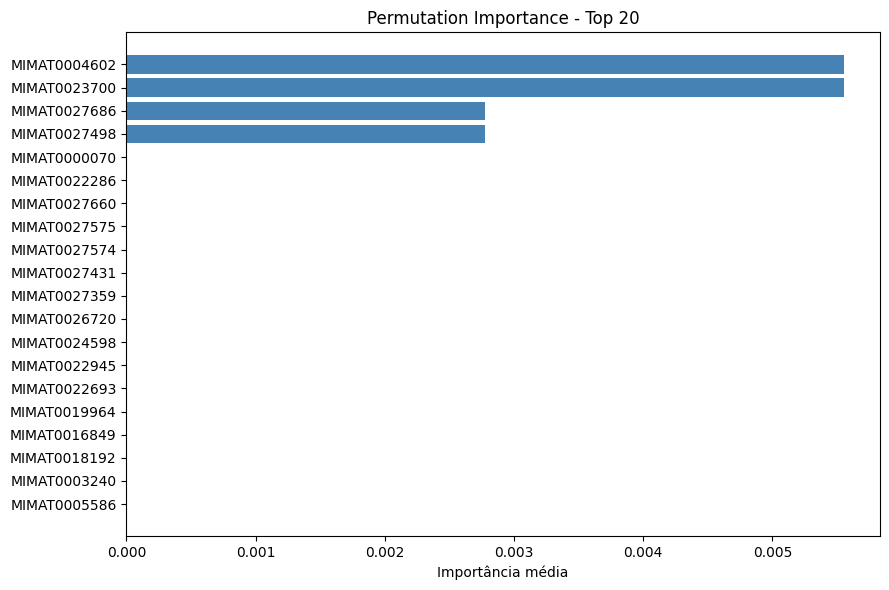

Figura salva: plots/SHAP_Top20.png


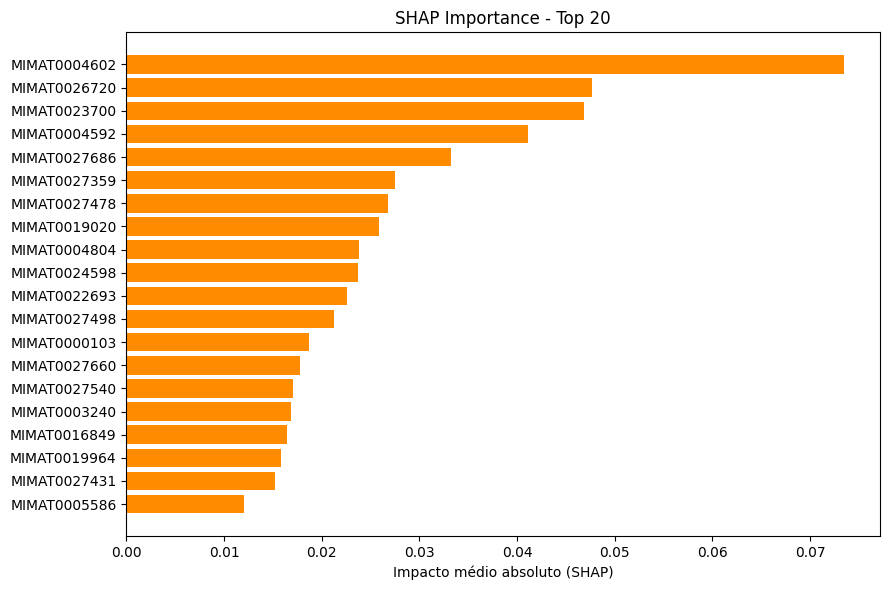


Correlação SHAP vs Permutation Importance: 0.6309


In [9]:
top_k = 20

print("\nGerando gráficos de interpretabilidade...")

perm_top = perm_df.head(top_k).iloc[::-1]
shap_top = shap_df.head(top_k).iloc[::-1]

fig, ax = plt.subplots(figsize=(9,6))
ax.barh(perm_top.index, perm_top.values,color="steelblue")
ax.set_title(f"Permutation Importance - Top {top_k}")
ax.set_xlabel("Importância média")
plt.tight_layout()
out_path = os.path.join("plots", f"Permutation_Top{top_k}.png")
fig.savefig(out_path,dpi=300,bbox_inches="tight")
print(f"Figura salva: {out_path}")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(9,6))
ax.barh(shap_top.index, shap_top.values,color="darkorange")
ax.set_title(f"SHAP Importance - Top {top_k}")
ax.set_xlabel("Impacto médio absoluto (SHAP)")
plt.tight_layout()
out_path = os.path.join("plots", f"SHAP_Top{top_k}.png")
fig.savefig(out_path,dpi=300,bbox_inches="tight")
print(f"Figura salva: {out_path}")
plt.show()
plt.close(fig)

corr = np.corrcoef(perm_df.values, shap_df.values)[0,1]
print(f"\nCorrelação SHAP vs Permutation Importance: {corr:.4f}")

Modelo RF GPU carregado com sucesso!

Realizando inferência...

Sample ID          : GSM1447570
Classe real        : PDAC
Classe prevista    : PDAC
Probabilidade PDAC : 0.7559


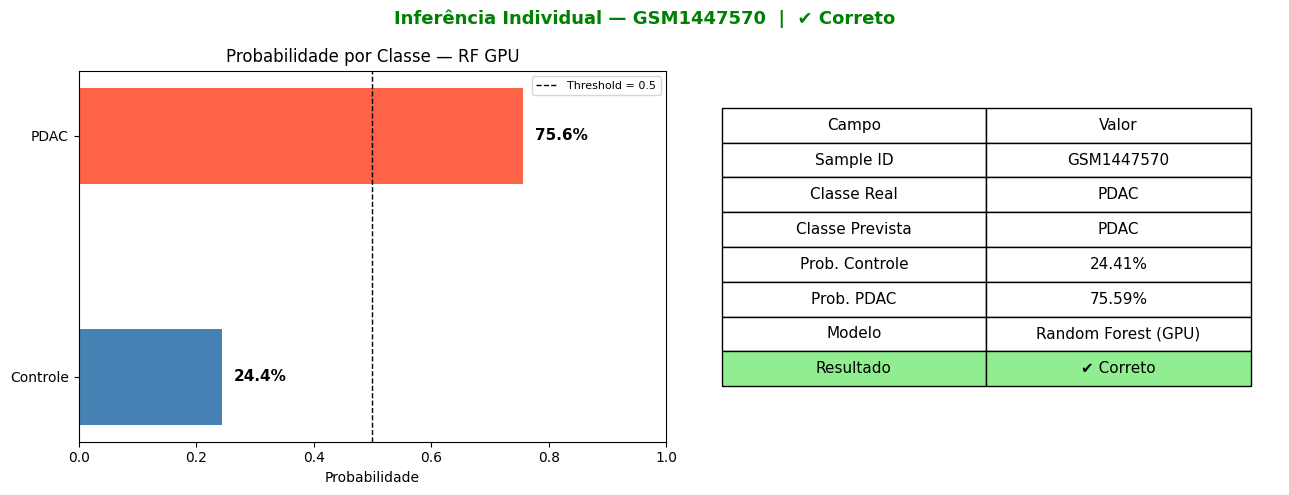

In [10]:
# CARREGAR MODELO
rf = load("models_RF_GPU/modelo_RF_GPU.joblib")
print("Modelo RF GPU carregado com sucesso!")

# CARREGAR BASE DE TESTE
dados_teste = pd.read_csv("../Databases/base_teste_boruta.csv")

# SELECIONAR PACIENTE ALEATÓRIO
paciente = dados_teste.sample(1, random_state=random.randint(1, 10000))

sample_id   = paciente["sample_id"].iloc[0]
classe_real = paciente["target"].iloc[0]

# PRÉ-PROCESSAMENTO (mesmo pipeline do treino)
paciente_df = paciente.drop(columns=["sample_id", "target", "split"])
paciente_df = paciente_df.fillna(paciente_df.mean())
paciente_df = paciente_df.reindex(columns=feature_names, fill_value=0)
paciente_in = paciente_df.values.astype(np.float32)

# INFERÊNCIA
print("\nRealizando inferência...\n")
proba = float(rf.predict_proba(paciente_in)[:, 1][0])
pred  = int(rf.predict(paciente_in)[0])
label_map = {0: "Controle", 1: "PDAC"}

print(f"Sample ID          : {sample_id}")
print(f"Classe real        : {label_map[classe_real]}")
print(f"Classe prevista    : {label_map[pred]}")
print(f"Probabilidade PDAC : {proba:.4f}")

# GRÁFICO
acerto     = (pred == classe_real)
cor_título = "green" if acerto else "red"
status     = "✔ Correto" if acerto else "✘ Incorreto"

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Inferência Individual — {sample_id}  |  {status}",
             fontsize=13, fontweight='bold', color=cor_título)

# SUBPLOT 1: barras de probabilidade
ax = axes[0]
bars = ax.barh(["Controle", "PDAC"], [1 - proba, proba],
               color=["steelblue", "tomato"], height=0.4)
ax.set_xlim(0, 1)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1, label='Threshold = 0.5')
ax.set_xlabel("Probabilidade")
ax.set_title("Probabilidade por Classe — RF GPU")
ax.legend(fontsize=8)

for bar, val in zip(bars, [1 - proba, proba]):
    ax.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
            f"{val:.1%}", va='center', fontsize=11, fontweight='bold')

# SUBPLOT 2: tabela de resumo
ax2 = axes[1]
ax2.axis('off')

linhas = [
    ("Sample ID",       str(sample_id)),
    ("Classe Real",     label_map[classe_real]),
    ("Classe Prevista", label_map[pred]),
    ("Prob. Controle",  f"{(1 - proba) * 100:.2f}%"),
    ("Prob. PDAC",      f"{proba * 100:.2f}%"),
    ("Modelo",          "Random Forest (GPU)"),
    ("Resultado",       status),
]

tabela = ax2.table(
    cellText=linhas,
    colLabels=["Campo", "Valor"],
    cellLoc='center',
    loc='center',
    bbox=[0.05, 0.15, 0.9, 0.75]
)
tabela.auto_set_font_size(False)
tabela.set_fontsize(11)

for col in [0, 1]:
    tabela[len(linhas), col].set_facecolor("lightgreen" if acerto else "lightsalmon")

plt.tight_layout()
plt.savefig(f"plots/inferencia_rf_gpu_{sample_id}.png", dpi=300, bbox_inches="tight")
plt.show()